In [34]:
words = open('names.txt', 'r').read().splitlines() # Open the file in read mode, read everything from it with /n between names (.read()) and then use splitstring to store it all in a list.

In [35]:
words[:15]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn',
 'abigail',
 'emily',
 'elizabeth',
 'mila',
 'ella']

In [36]:
len(words)

32033

In [37]:
max(words, key=len) # get the max of the words using len as the thing you want the max of.

'muhammadibrahim'

In [38]:
min(words, key=len)

'an'

In [39]:
min(len(w) for w in words)

2

In [40]:
max(len(w) for w in words) # max function keeps picking up max as the looping goes on.

15

In [41]:
# Next up we will build a bigram language model. In that, you only work with two characters at a time. We look at a given character and try to predict the next in the sequence. 

In [42]:
# We will use it to predict what characters follow a certain character in most names For example, what character is most likely to come after an 'e'?

Part 1: Exploring the bigrams in the dataset

In [43]:
b = {} # to map bigrams - stores the bigrams.
for w in words: # For the first word (emma)
    chs = ['<S>'] + list(w) + ['<E>'] # hallucinate special start and end character.
    for ch1, ch2 in zip(chs, chs[1:]): # zip takes two or more sequences (here, list of 1 char strings) and pairs them in their elements. ch1 refers to zip 1s elements and ch2 refers to zip2s elements, and by doing a shift left on the second argument we have each character paired with the next one.
        bigram = (ch1, ch2)# a tuple of ch1 and ch2
        b[bigram] = b.get(bigram, 0) + 1 # look at the dictionary, write +1 to the keys value (value is count of how many times appeared) and if it doesn't exist then it gets added and does 0 + 1 = 1 for value.

# <S> e m m a <E>
#  e  m m a <E>
# pairs: <S>e em mm ma a<E> (and last <E> gets dropped since it has no pair)

In [44]:
sorted(b.items(), key = lambda kv: -kv[1])  # the lambda here returns the count of each dictionary element; it functions like the * shown below.
# b.items() turns the dict into a list of (key, value) tuples. Use it to sort dicts like that.
# sorted will go through the list of tuples and run each through the lambda we made it will get the value of each key adn will return from min to max - i.e sort our dictionary so keys with least value show up first and more show up last.
# the lambda we amde just asks sorted to sort by the value of the second element in tuple created by .item() - and the second element is the value of each key.

# *:
# def get_count(item);
#      return item[1]
# so think of lambda as a general def and kv as the argument to this function.

#TLDR the key is what sorted uses to sort a list here we used the second element of the tuple which is the number of occurrences of the bigram.


[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [45]:
# (Part 5) Now we will count bigrams in a 2D torch sensor ("training the model")

In [46]:
import torch

In [47]:
N = torch.zeros((28,28), dtype = torch.int32)

In [48]:
chars = sorted(list(set(''.join(words)))) # join makes the words file into one long string with no spaces between names, set throws out all duplicate characters, list converts it from a set to a list and sorted sorts the unique characters alphabetically
stoi = {s:i for i,s in enumerate(chars)} # enumerate is like zip but it zips with index instead of a seperate sequence.
stoi['<S>'] = 26
stoi['<E>'] = 27

In [49]:
stoi

{'a': 0,
 'b': 1,
 'c': 2,
 'd': 3,
 'e': 4,
 'f': 5,
 'g': 6,
 'h': 7,
 'i': 8,
 'j': 9,
 'k': 10,
 'l': 11,
 'm': 12,
 'n': 13,
 'o': 14,
 'p': 15,
 'q': 16,
 'r': 17,
 's': 18,
 't': 19,
 'u': 20,
 'v': 21,
 'w': 22,
 'x': 23,
 'y': 24,
 'z': 25,
 '<S>': 26,
 '<E>': 27}

In [52]:
for w in words: 
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]): 
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1 

In [51]:
N

tensor([[ 556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568, 2528,
         1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,  182,
         2050,  435,    0, 6640],
        [ 321,   38,    1,   65,  655,    0,    0,   41,  217,    1,    0,  103,
            0,    4,  105,    0,    0,  842,    8,    2,   45,    0,    0,    0,
           83,    0,    0,  114],
        [ 815,    0,   42,    1,  551,    0,    2,  664,  271,    3,  316,  116,
            0,    0,  380,    1,   11,   76,    5,   35,   35,    0,    0,    3,
          104,    4,    0,   97],
        [1303,    1,    3,  149, 1283,    5,   25,  118,  674,    9,    3,   60,
           30,   31,  378,    0,    1,  424,   29,    4,   92,   17,   23,    0,
          317,    1,    0,  516],
        [ 679,  121,  153,  384, 1271,   82,  125,  152,  818,   55,  178, 3248,
          769, 2675,  269,   83,   14, 1958,  861,  580,   69,  463,   50,  132,
         1070,  181,    0, 3983],
        [ 242,    0,

In [55]:
itos = {i:s for s, i in stoi.items()}

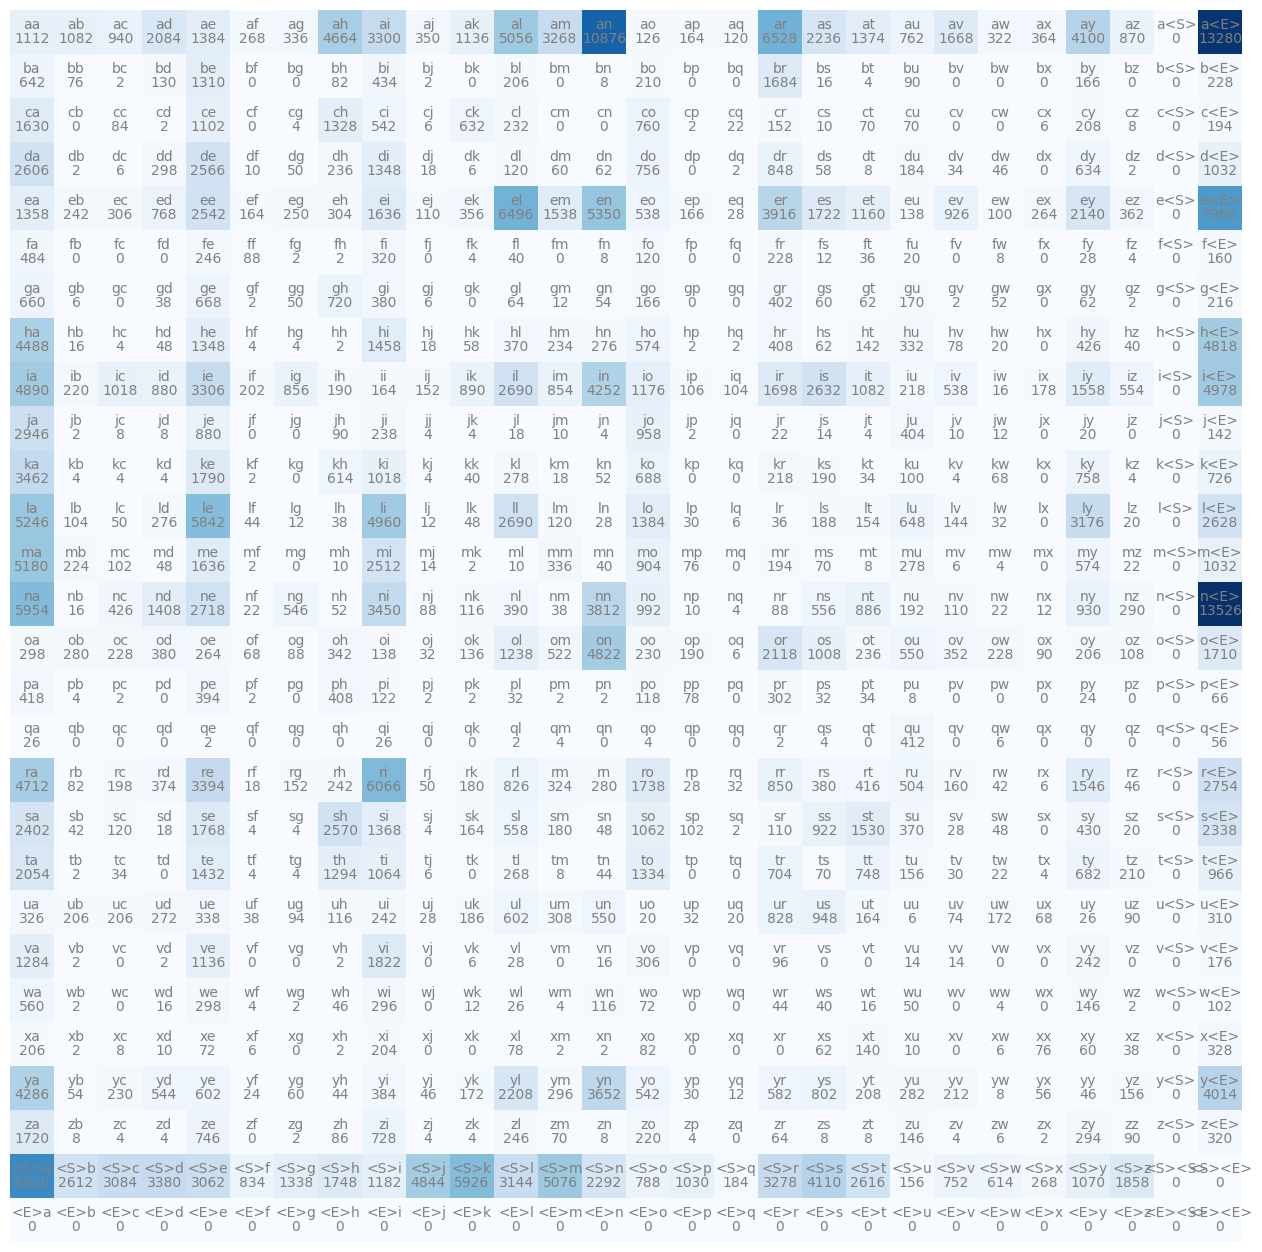

In [60]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(28):
    for j in range(28):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha = "center", va = "bottom", color = 'gray')
        plt.text(j, i, N[i, j].item(), ha = "center", va = "top", color="gray")
    plt.axis('off')

Part 6: Deleting Spurious (S) and (E) tokens in favour of a single token.